In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import shap

from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

0. Выбор датасета

https://huggingface.co/datasets/ZakyF/Global-Digital-Wellnes

In [6]:
data = pd.read_csv('global_digital_wellness_dataset.csv')

Описание колонок

- User_ID — Unique identifier (1 to 10,000)
- Region — Geographic location (North America, Europe, Asia-Pacific, LATAM, Africa, Middle East)
- Age_Group — Generational bracket (Gen Z, Millennial, Gen X, Boomer)
- Daily_Screen_Time — Hours per day (continuous, 0.5-16 range)
- Subscription_Count — Number of paid services (discrete, 0-15)
- Digital_Fatigue_Score — Self-reported fatigue level (ordinal, 1-10 scale)
- Sleep_Quality — Sleep quality category (Good, Fair, Excelent, Poor)
- Monthly_Digital_Spend — USD spending on digital services (continuous)
- User_Review_Note — Text review about digital wellness (text/NLP)
- Sentiment_Index — Computed sentiment score (continuous, -1 to 1)
- Lifestyle_Class — Target: Digital Addict / Balanced / Minimalist

1. Выбор и обоснование метрики для оценки качетсва

Задача для модели: предсказание Lifestyle_Class. Это задача классификации. Наилучшей метрикой для такой задачи будет являться метрика Accuracy (доля правильных ответов), т. к. это стандартная метрика для задачи классификации.

2. EDA и предобработка

In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   User_ID                10000 non-null  int64  
 1   Region                 10000 non-null  str    
 2   Age_Group              10000 non-null  str    
 3   Daily_Screen_Time      10000 non-null  float64
 4   Subscription_Count     10000 non-null  int64  
 5   Monthly_Digital_Spend  10000 non-null  float64
 6   Digital_Fatigue_Score  10000 non-null  int64  
 7   Sleep_Quality          10000 non-null  str    
 8   Sentiment_Index        10000 non-null  float64
 9   User_Review_Note       10000 non-null  str    
 10  Lifestyle_Class        10000 non-null  str    
dtypes: float64(3), int64(3), str(5)
memory usage: 2.0 MB


11 колонок. int/str/float. Пропусков данных нет.

ID человека не влияет на предсказание модели - это ненужный стобец. Также удалим столбец User_Review_Note.

In [8]:
data.drop(columns=['User_ID', 'User_Review_Note'], inplace=True)
data

,Region,Age_Group,Daily_Screen_Time,Subscription_Count,Monthly_Digital_Spend,Digital_Fatigue_Score,Sleep_Quality,Sentiment_Index,Lifestyle_Class
0,Europe,Millennial (25-40),6.51,5,991.984804,6,Good,-0.41,Balanced
1,Middle East,Millennial (25-40),6.32,5,75.830000,7,Fair,-0.24,Balanced
2,LATAM,Gen Z (18-24),9.12,2,10.570000,7,Fair,-0.42,Balanced
3,Asia-Pacific,Gen X (41-56),4.42,4,50.060000,4,Good,0.39,Balanced
4,North America,Millennial (25-40),8.84,5,100.050000,8,Fair,-0.46,Balanced
...,...,...,...,...,...,...,...,...,...
9995,Africa,Boomer (57+),2.11,1,0.000000,2,Fair,0.92,Minimalist
9996,Africa,Gen Z (18-24),8.39,4,26.920000,6,Fair,-0.00,Balanced
9997,Middle East,Millennial (25-40),6.72,7,77.590000,7,Fair,-0.25,Balanced
9998,Asia-Pacific,Millennial (25-40),9.36,5,50.780000,7,Good,-0.18,Balanced


Описание численных признаков

In [9]:
data.describe()

,Daily_Screen_Time,Subscription_Count,Monthly_Digital_Spend,Digital_Fatigue_Score,Sentiment_Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,6.345082,3.834700,53.052580,5.087700,0.089541
std,2.497729,1.780588,57.985142,1.515136,0.377405
min,0.500000,1.000000,0.000000,1.000000,-1.000000
25%,4.530000,3.000000,29.030000,4.000000,-0.180000
50%,6.350000,4.000000,46.240000,5.000000,0.050000
75%,8.080000,5.000000,66.980000,6.000000,0.330000
max,15.989983,14.000000,998.652353,9.000000,1.000000


Зависимость уровня жизни от количества экранного времени.

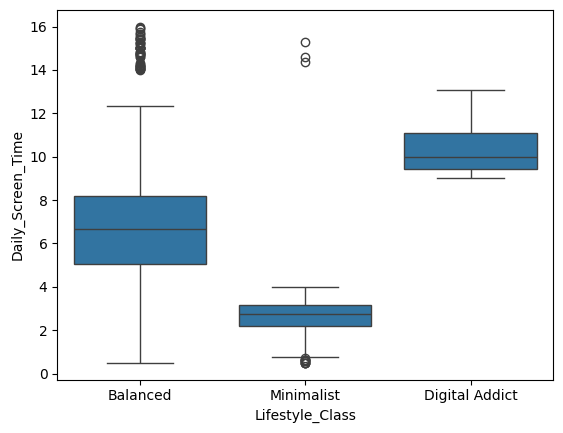

In [10]:
sns.boxplot(x='Lifestyle_Class', y='Daily_Screen_Time', data=data)
plt.show()

Предобработка данных

Кодирование категориальных переменных

In [11]:
df = pd.get_dummies(data, columns=['Region'], prefix='region')
df = pd.get_dummies(df, columns=['Age_Group'], prefix='age')


Порядковые признаки

In [12]:
df['Sleep_Quality'] = df['Sleep_Quality'].map({'Poor': 0, 'Fair': 1, 'Good': 2, 'Excellent': 3})
df['Lifestyle_Class'] = df['Lifestyle_Class'].map({'Minimalist': 0, 'Balanced': 1, 'Digital Addict': 2})


Масштабирование числовых признаков

In [13]:
scaler = StandardScaler()
numeric_columns = ['Daily_Screen_Time', 'Subscription_Count', 'Monthly_Digital_Spend', 'Sentiment_Index', 'Digital_Fatigue_Score']
df[numeric_columns] = scaler.fit_transform(df[numeric_columns])
df

,Daily_Screen_Time,Subscription_Count,Monthly_Digital_Spend,Digital_Fatigue_Score,Sleep_Quality,Sentiment_Index,Lifestyle_Class,region_Africa,region_Asia-Pacific,region_Europe,region_LATAM,region_Middle East,region_North America,age_Boomer (57+),age_Gen X (41-56),age_Gen Z (18-24),age_Millennial (25-40)
0,0.066030,0.654480,16.193444,0.602154,2,-1.323686,1,False,False,True,False,False,False,False,False,False,True
1,-0.010042,0.654480,0.392834,1.262194,1,-0.873219,1,False,False,False,False,True,False,False,False,False,True
2,1.111032,-1.030442,-0.732683,1.262194,1,-1.350184,1,False,False,False,True,False,False,False,False,True,False
3,-0.770771,0.092839,-0.051612,-0.717925,2,0.796158,1,False,True,False,False,False,False,False,True,False,False
4,0.998924,0.654480,0.810548,1.922233,1,-1.456176,1,False,False,False,False,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,-1.695658,-1.592082,-0.914980,-2.038004,1,2.200554,0,True,False,False,False,False,False,True,False,False,False
9996,0.818752,0.092839,-0.450700,0.602154,1,-0.237266,1,True,False,False,False,False,False,False,False,True,False
9997,0.150111,1.777760,0.423189,1.262194,1,-0.899717,1,False,False,False,False,True,False,False,False,False,True
9998,1.207124,0.654480,-0.039194,1.262194,2,-0.714231,1,False,True,False,False,False,False,False,False,False,True


Матрица корреляции

In [14]:
df_corr = df.corr()
df_corr

,Daily_Screen_Time,Subscription_Count,Monthly_Digital_Spend,Digital_Fatigue_Score,Sleep_Quality,Sentiment_Index,Lifestyle_Class,region_Africa,region_Asia-Pacific,region_Europe,region_LATAM,region_Middle East,region_North America,age_Boomer (57+),age_Gen X (41-56),age_Gen Z (18-24),age_Millennial (25-40)
Daily_Screen_Time,1.000000,0.194350,0.108292,0.747950,-0.434406,-0.656742,0.486730,-0.153872,0.180988,0.017456,-0.116722,-0.130302,0.043788,-0.618440,-0.339203,0.638676,0.238000
Subscription_Count,0.194350,1.000000,0.354271,0.600355,-0.025835,-0.531835,0.495553,-0.002712,-0.009334,0.019575,-0.005410,0.001108,-0.002269,-0.564717,0.126049,-0.311306,0.581593
Monthly_Digital_Spend,0.108292,0.354271,1.000000,0.268377,-0.016909,-0.245235,0.190644,-0.140208,-0.080586,0.109436,-0.104356,-0.010671,0.171858,-0.212842,0.043750,-0.118234,0.223518
Digital_Fatigue_Score,0.747950,0.600355,0.268377,1.000000,-0.304101,-0.879180,0.610602,-0.158620,0.171454,0.026788,-0.118287,-0.123379,0.046137,-0.719811,-0.091605,0.207104,0.455961
Sleep_Quality,-0.434406,-0.025835,-0.016909,-0.304101,1.000000,0.264987,-0.155299,0.063942,-0.082172,-0.021940,0.056467,0.049114,0.000976,0.201580,0.251937,-0.321990,-0.112014
Sentiment_Index,-0.656742,-0.531835,-0.245235,-0.879180,0.264987,1.000000,-0.531688,0.143261,-0.155577,-0.018444,0.106018,0.109517,-0.044442,0.629772,0.088229,-0.179640,-0.407874
Lifestyle_Class,0.486730,0.495553,0.190644,0.610602,-0.155299,-0.531688,1.000000,-0.021476,0.038194,0.006419,-0.019126,-0.010281,-0.015805,-0.717677,0.172884,0.178414,0.230489
region_Africa,-0.153872,-0.002712,-0.140208,-0.158620,0.063942,0.143261,-0.021476,1.000000,-0.210547,-0.133476,-0.102399,-0.078015,-0.143868,0.000185,-0.002815,0.006502,-0.003120
region_Asia-Pacific,0.180988,-0.009334,-0.080586,0.171454,-0.082172,-0.155577,0.038194,-0.210547,1.000000,-0.348612,-0.267445,-0.203760,-0.375754,-0.006106,-0.000462,0.003411,0.002139
region_Europe,0.017456,0.019575,0.109436,0.026788,-0.021940,-0.018444,0.006419,-0.133476,-0.348612,1.000000,-0.169546,-0.129173,-0.238208,-0.008180,-0.002898,0.000661,0.008393


Из матрицы видно, что регион мало влияет на итоговый уровень. Тогда удалим столбцы регионов.

In [15]:
df.drop(columns=['region_Africa', 'region_Asia-Pacific', 'region_Europe', 'region_LATAM', 'region_Middle East',	'region_North America'], inplace=True)
df

,Daily_Screen_Time,Subscription_Count,Monthly_Digital_Spend,Digital_Fatigue_Score,Sleep_Quality,Sentiment_Index,Lifestyle_Class,age_Boomer (57+),age_Gen X (41-56),age_Gen Z (18-24),age_Millennial (25-40)
0,0.066030,0.654480,16.193444,0.602154,2,-1.323686,1,False,False,False,True
1,-0.010042,0.654480,0.392834,1.262194,1,-0.873219,1,False,False,False,True
2,1.111032,-1.030442,-0.732683,1.262194,1,-1.350184,1,False,False,True,False
3,-0.770771,0.092839,-0.051612,-0.717925,2,0.796158,1,False,True,False,False
4,0.998924,0.654480,0.810548,1.922233,1,-1.456176,1,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...
9995,-1.695658,-1.592082,-0.914980,-2.038004,1,2.200554,0,True,False,False,False
9996,0.818752,0.092839,-0.450700,0.602154,1,-0.237266,1,False,False,True,False
9997,0.150111,1.777760,0.423189,1.262194,1,-0.899717,1,False,False,False,True
9998,1.207124,0.654480,-0.039194,1.262194,2,-0.714231,1,False,False,False,True


3. Постройка и оценка качества бейзлайна

In [16]:
X = df.drop(columns=['Lifestyle_Class'])
y = df['Lifestyle_Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Подготовка и обучение модели

In [17]:
model = XGBClassifier(
    objective='multi:softprob',   
    num_class=3,                  
    n_estimators=300,             
    learning_rate=0.05,           
    max_depth=6,                  
    min_child_weight=1,           
    subsample=0.8,               
    colsample_bytree=0.8,        
    gamma=0,                      
    reg_alpha=0,                 
    reg_lambda=1,                 
    random_state=42,
    eval_metric='mlogloss'
)

model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

Оценка качества

In [18]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Точность модели: {accuracy * 100:.4f}%')

Точность модели: 99.8000%


4. Подбор гиперпараметров

In [19]:
param_grid = {
    'max_depth': [4, 5, 6, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [200, 300, 500],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

classifier = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    random_state=42
)

new_model = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

new_model.fit(X_train, y_train)
new_model.best_params_

Fitting 5 folds for each of 324 candidates, totalling 1620 fits


{'colsample_bytree': 0.8,
 'learning_rate': 0.05,
 'max_depth': 5,
 'n_estimators': 200,
 'subsample': 0.9}

In [23]:
new_model.best_score_

np.float64(0.9998750000000001)

In [21]:
y_pred = new_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Точность модели: {accuracy * 100:.4f}%')

Точность модели: 99.8500%


5. Интерпретация модели

Важность признаков

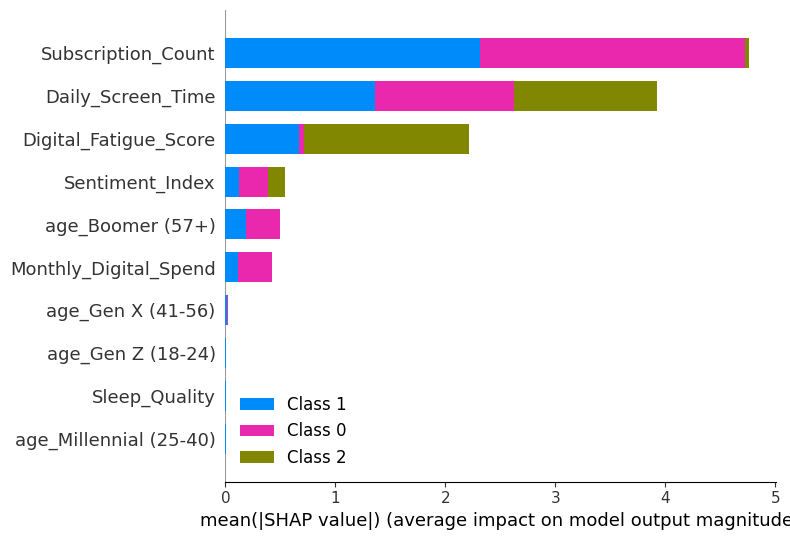

In [22]:
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)